In [3]:
# Import required libraries
import nltk
from nltk.corpus import movie_reviews
import pandas as pd
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download movie reviews
nltk.download('movie_reviews')

# Prepare reviews and labels
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Shuffle the data
random.shuffle(documents)

# Convert reviews into text
reviews = [" ".join(doc) for doc, category in documents]
sentiments = [category for doc, category in documents]

# Create DataFrame
df = pd.DataFrame({'Review': reviews, 'Sentiment': sentiments})

# Show sample data
print(df.head())

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Review'])
y = df['Sentiment']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\vr204\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


                                              Review Sentiment
0  don ' t get me wrong -- i tend to appreciate b...       neg
1  when i initially set out to review this film ,...       pos
2  the tagline for this film is : " some houses a...       neg
3  fact that charles bronson represents one of th...       neg
4  " the celebration " is one of an elite kind of...       pos
Accuracy: 0.825

Classification Report:
               precision    recall  f1-score   support

         neg       0.82      0.84      0.83       202
         pos       0.83      0.81      0.82       198

    accuracy                           0.82       400
   macro avg       0.83      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400


Confusion Matrix:
 [[170  32]
 [ 38 160]]


## Insights

- The sentiment analysis model achieved an accuracy of 82%.
- The model achieved an F1-score of 0.82 for both positive and negative reviews.
- The model correctly classified most of the reviews.
- Some positive reviews were incorrectly classified as negative, while some negative reviews were classified as positive.
- Overall, the model shows good performance in identifying the sentiment of movie reviews.

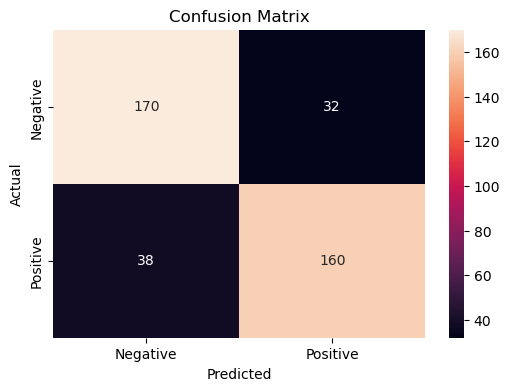

In [4]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()